# Дзен × Арктика: аналитика и расчёты PR-кампании «Ближе, чем кажется»

Ноутбук — аналитическая часть проектной задачи VK: PR-кампания Дзена об Арктике и Северном морском пути (декабрь 2026 — март 2027).

Что внутри:

1. Ключевые факты и источники
2. Динамика грузопотока по Севморпути и цели до 2035 года
3. Календарь федеральной повестки: к каким событиям привязываем инфоповоды
4. Аудитории B2G / B2M / B2C
5. Контент-план кор-проекта «Широта 66°»
6. Скоринг лидеров мнений
7. Модель виральной механики «Мой арктический след»
8. Медиамодель: охваты и инфоповоды
9. KPI и бюджет
10. Выводы

Все расчёты воспроизводимы: достаточно `pandas`, `numpy`, `matplotlib`. Таблицы выгружаются в папку `output/`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

os.makedirs('output', exist_ok=True)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 200)

INK, ICE, CYAN, ORANGE, GREY = '#0B1B2B', '#EEF3F6', '#1FA3C4', '#FF5A1F', '#8A9BA8'
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GREY, 'axes.labelcolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.titleweight': 'bold', 'axes.titlesize': 13, 'figure.dpi': 110,
})

## 1. Ключевые факты и источники

Собираем опорные цифры, на которых будет держаться вся коммуникация. Правило кампании простое: каждая цифра в материалах Дзена должна иметь ссылку на первоисточник.

In [2]:
facts = pd.DataFrame([
    ('Грузопоток по СМП, 2024', '37,89 млн т (рекорд)', 'atomic-energy.ru', 'https://www.atomic-energy.ru/news/2025/01/10/152541'),
    ('Грузопоток по СМП, 2025', '37,04 млн т; 86% — углеводороды', 'Российская газета', 'https://rg.ru/2026/01/19/led-tronulsia.html'),
    ('Транзитные контейнеры по СМП, 2025', '≈400 тыс. т (рост в 2,6 раза)', 'Российская газета', 'https://rg.ru/2026/01/19/led-tronulsia.html'),
    ('Рейсы по СМП, 2025', '1 340 рейсов, +20% к 2024', 'atomic-energy.ru', 'https://www.atomic-energy.ru/news/2025/10/28/160550'),
    ('Прогноз на 2026', '40 млн т; за полгода 18,8 млн т (+13,7%)', 'atomic-energy.ru', 'https://www.atomic-energy.ru/news/2026/07/17/167192'),
    ('Цели', '150 млн т к 2030, 220 млн т к 2035', 'Российская газета', 'https://rg.ru/2026/01/19/led-tronulsia.html'),
    ('Атомный ледокольный флот', '8 судов в строю; «Лидер» (120 МВт, лёд до 3 м) — к 2030', 'Профиль', 'https://profile.ru/news/politics/samyj-moshhnyj-v-mire-kogda-dostroyat-atomnyj-ledokol-lider-i-zachem-on-nuzhen-rossii-1885253/'),
    ('Население АЗРФ', '≈2,4 млн чел., 86% в городах', 'Минэкономразвития Мурманской обл.', 'https://minec.gov-murman.ru/activities/arktika-v-tsifrakh'),
    ('Газ из Арктики', '≈83% российского газа добывается в Арктике', 'Минэкономразвития Мурманской обл.', 'https://minec.gov-murman.ru/activities/arktika-v-tsifrakh'),
    ('Арктическая ипотека', '2%, до 9 млн ₽, до 31.12.2030', 'Мой бюджет / Mail', 'https://finance.mail.ru/card/arkticheskaya-ipoteka-892/'),
    ('Поручения по Арктике', 'Апрель 2026: СПГ, ледоколы 22220, Трансарктический коридор, северный завоз', 'Нефтегаз.RU', 'https://neftegaz.ru/news/gosreg/926127-v-putin-zadal-vektor-razvitiya-arktiki-ot-gazoprovodov-i-spg-do-ledokolnogo-flota-i-transarktichesko/'),
    ('Год Арктики — 2027', 'Проект указа, оргкомитет во главе с Ю. Трутневым', 'Гарант', 'https://www.garant.ru/products/ipo/prime/doc/56934438/'),
    ('Программа Года Арктики', 'Ассоциация полярников собирает предложения', 'ComNews', 'https://www.comnews.ru/content/241858/2025-10-20/2025-w43/1018/associaciya-polyarnikov-obyavlyaet-o-sbore-predlozheniy-dlya-formirovaniya-programmy-goda-arktiki-rossii'),
    ('Год географии — 2027', 'Президент предложил объявить 2027-й Годом географии (съезд РГО, октябрь 2025)', 'Российская газета', 'https://rg.ru/2025/10/23/putin-predlozhil-obiavit-2027-god-godom-geografii.html'),
    ('Форум в Мурманске', '«Арктика — территория диалога» ежегодно с 2027 г.', 'eco-tourism.expert', 'https://eco-tourism.expert/en/news/international-arctic-forum-to-be-held-in-murmansk-from-2027'),
], columns=['Факт', 'Значение', 'Источник', 'Ссылка'])
facts.to_csv('output/facts_sources.csv', index=False)
facts[['Факт', 'Значение', 'Источник']]

,Факт,Значение,Источник
0,"Грузопоток по СМП, 2024","37,89 млн т (рекорд)",atomic-energy.ru
1,"Грузопоток по СМП, 2025","37,04 млн т; 86% — углеводороды",Российская газета
2,"Транзитные контейнеры по СМП, 2025","≈400 тыс. т (рост в 2,6 раза)",Российская газета
3,"Рейсы по СМП, 2025","1 340 рейсов, +20% к 2024",atomic-energy.ru
4,Прогноз на 2026,"40 млн т; за полгода 18,8 млн т (+13,7%)",atomic-energy.ru
5,Цели,"150 млн т к 2030, 220 млн т к 2035",Российская газета
6,Атомный ледокольный флот,"8 судов в строю; «Лидер» (120 МВт, лёд до 3 м) — к 2030",Профиль
7,Население АЗРФ,"≈2,4 млн чел., 86% в городах",Минэкономразвития Мурманской обл.
8,Газ из Арктики,≈83% российского газа добывается в Арктике,Минэкономразвития Мурманской обл.
9,Арктическая ипотека,"2%, до 9 млн ₽, до 31.12.2030",Мой бюджет / Mail


## 2. Грузопоток по Севморпути: откуда и куда

За 11 лет объём вырос более чем в 9 раз, но с 2021 года рост почти остановился — 34–38 млн т в год. Цель на 2030-й — 150 млн т, то есть в четыре раза больше, чем сейчас.

Для коммуникации это важная деталь. Разрыв между фактом и целью — это не «всё хорошо», а сюжет: чтобы его закрыть, нужны ледоколы, порты, люди. Про это и стоит рассказывать.

Среднегодовой рост 2014–2025: 22.5%
Среднегодовой рост 2021–2025: 1.5%
Нужный рост 2026–2030, чтобы выйти на 150 млн т: 39.2% в год


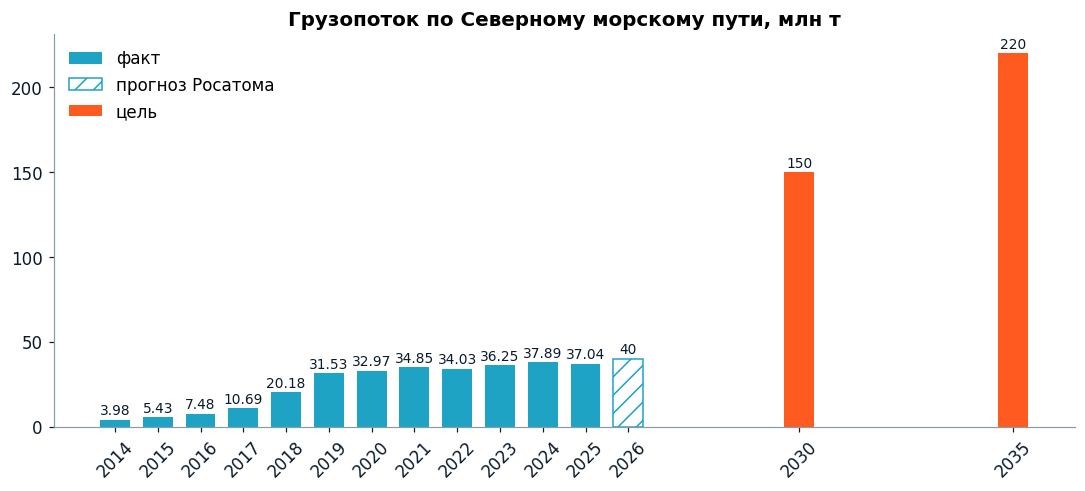

In [3]:
cargo = pd.DataFrame({
    'year':   [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    'mln_t':  [3.98, 5.43, 7.48, 10.69, 20.18, 31.53, 32.97, 34.85, 34.03, 36.25, 37.89, 37.04, 40.0],
    'type':   ['факт'] * 12 + ['прогноз'],
})
targets = pd.DataFrame({'year': [2030, 2035], 'mln_t': [150, 220], 'type': 'цель'})

cagr_14_25 = (37.04 / 3.98) ** (1 / 11) - 1
cagr_21_25 = (37.04 / 34.85) ** (1 / 4) - 1
need_26_30 = (150 / 40) ** (1 / 4) - 1
print(f'Среднегодовой рост 2014–2025: {cagr_14_25:.1%}')
print(f'Среднегодовой рост 2021–2025: {cagr_21_25:.1%}')
print(f'Нужный рост 2026–2030, чтобы выйти на 150 млн т: {need_26_30:.1%} в год')

fig, ax = plt.subplots(figsize=(10, 4.6))
f = cargo[cargo.type == 'факт']
ax.bar(f.year, f.mln_t, color=CYAN, width=0.7, label='факт')
ax.bar(2026, 40, color='white', edgecolor=CYAN, hatch='//', width=0.7, label='прогноз Росатома')
ax.bar(targets.year, targets.mln_t, color=ORANGE, width=0.7, label='цель')
for x, y in zip(list(cargo.year) + list(targets.year), list(cargo.mln_t) + list(targets.mln_t)):
    ax.text(x, y + 3, f'{y:g}', ha='center', fontsize=9, color=INK)
ax.set_title('Грузопоток по Северному морскому пути, млн т')
ax.set_xticks(list(range(2014, 2027)) + [2030, 2035])
ax.tick_params(axis='x', rotation=45)
ax.legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.savefig('output/nsr_cargo.png', dpi=160); plt.show()

## 3. Календарь повестки

Кампания привязана к событиям, которые и так попадут в федеральные новости. Задача Дзена — прийти туда не с рекламой, а со своим поводом.

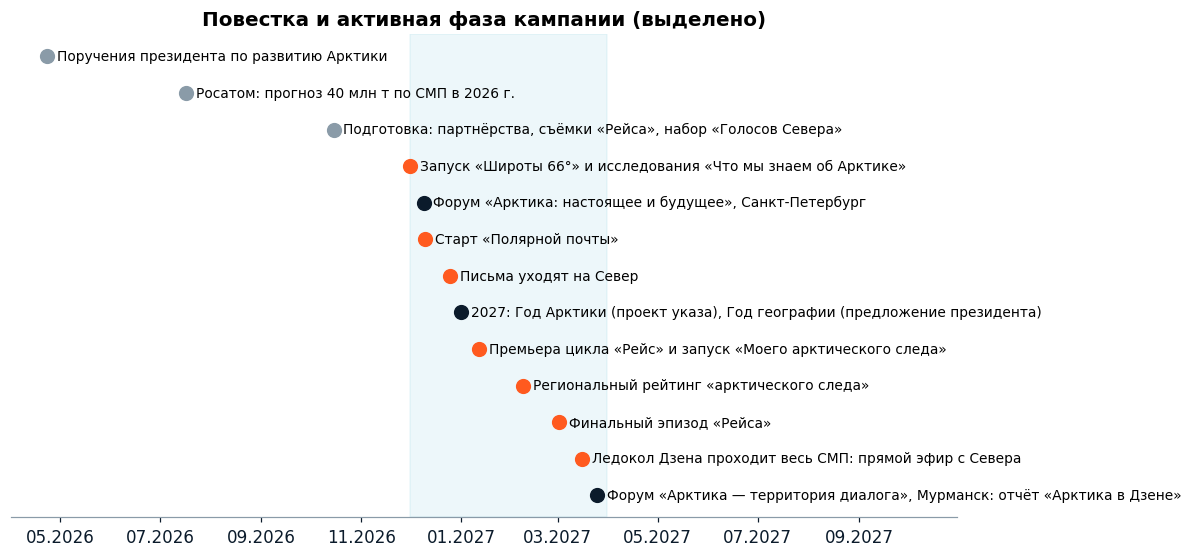

In [4]:
agenda = pd.DataFrame([
    ('2026-04-23', 'Поручения президента по развитию Арктики', 'B2G', 'контекст'),
    ('2026-07-17', 'Росатом: прогноз 40 млн т по СМП в 2026 г.', 'B2B', 'контекст'),
    ('2026-10-15', 'Подготовка: партнёрства, съёмки «Рейса», набор «Голосов Севера»', 'все', 'подготовка'),
    ('2026-12-01', 'Запуск «Широты 66°» и исследования «Что мы знаем об Арктике»', 'B2C', 'Дзен'),
    ('2026-12-09', 'Форум «Арктика: настоящее и будущее», Санкт-Петербург', 'B2G', 'внешнее'),
    ('2026-12-10', 'Старт «Полярной почты»', 'B2C', 'Дзен'),
    ('2026-12-25', 'Письма уходят на Север', 'B2C', 'Дзен'),
    ('2027-01-01', '2027: Год Арктики (проект указа), Год географии (предложение президента)', 'B2G', 'внешнее'),
    ('2027-01-12', 'Премьера цикла «Рейс» и запуск «Моего арктического следа»', 'B2C', 'Дзен'),
    ('2027-02-08', 'Региональный рейтинг «арктического следа»', 'B2M', 'Дзен'),
    ('2027-03-02', 'Финальный эпизод «Рейса»', 'B2C', 'Дзен'),
    ('2027-03-16', 'Ледокол Дзена проходит весь СМП: прямой эфир с Севера', 'B2C', 'Дзен'),
    ('2027-03-25', 'Форум «Арктика — территория диалога», Мурманск: отчёт «Арктика в Дзене»', 'B2G', 'внешнее'),
], columns=['date', 'event', 'audience', 'kind'])
agenda['date'] = pd.to_datetime(agenda['date'])
agenda.to_csv('output/agenda_calendar.csv', index=False)

colors = {'контекст': GREY, 'подготовка': GREY, 'внешнее': INK, 'Дзен': ORANGE}
fig, ax = plt.subplots(figsize=(11, 5.2))
for i, r in agenda.reset_index(drop=True).iterrows():
    y = len(agenda) - i
    ax.scatter(r.date, y, s=80, color=colors[r.kind], zorder=3)
    ax.text(r.date + pd.Timedelta(days=6), y, r.event, va='center', fontsize=9)
ax.axvspan(pd.Timestamp('2026-12-01'), pd.Timestamp('2027-03-31'), color=CYAN, alpha=0.08)
ax.set_yticks([]); ax.spines['left'].set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))
ax.set_xlim(pd.Timestamp('2026-04-01'), pd.Timestamp('2027-10-31'))
ax.set_title('Повестка и активная фаза кампании (выделено)')
plt.tight_layout(); plt.savefig('output/agenda.png', dpi=160); plt.show()

## 4. Три аудитории и что каждая получает

Одна идея, три разных «зачем». Если хоть одной аудитории нечего взять — кампания разваливается на спецпроект для галочки.

In [5]:
audiences = pd.DataFrame([
    ('B2G', 'Минвостокразвития, Росатом (оператор СМП), губернаторы арктических регионов, оргкомитет Года Арктики',
     'Нацпроект понятен людям, есть измеримый интерес к теме',
     'Отчёт «Арктика в Дзене»: что читают, что непонятно, какие вопросы задают; площадка для объяснения мер (ипотека, северный завоз)'),
    ('B2M', 'Федеральные и региональные СМИ на Дзене, отраслевые редакции',
     'Трафик и эксклюзивы по сложной теме',
     '«Арктический пул»: доступ к героям и съёмкам, данные для материалов, приоритет в рекомендациях'),
    ('B2B', 'Индустриальные компании, рекламодатели',
     'Репутация работодателя, понятная история бизнеса',
     'Истории людей из компаний, интеграции в «Людей 66°», данные «арктического следа»'),
    ('B2C', 'Жители России 25–55 лет, читают новости, думают о будущем страны и своём',
     'Понять, зачем это всё и как касается лично меня',
     'Простые объяснения, живые герои, личное участие: письмо на Север, свой «арктический след»'),
], columns=['Аудитория', 'Кто это', 'Что им нужно', 'Что даёт кампания'])
audiences.to_csv('output/audiences.csv', index=False)
audiences

,Аудитория,Кто это,Что им нужно,Что даёт кампания
0,B2G,"Минвостокразвития, Росатом (оператор СМП), губернаторы арктических регионов, оргкомитет Года Арктики","Нацпроект понятен людям, есть измеримый интерес к теме","Отчёт «Арктика в Дзене»: что читают, что непонятно, какие вопросы задают; площадка для объяснения мер (ипотека, севе..."
1,B2M,"Федеральные и региональные СМИ на Дзене, отраслевые редакции",Трафик и эксклюзивы по сложной теме,"«Арктический пул»: доступ к героям и съёмкам, данные для материалов, приоритет в рекомендациях"
2,B2B,"Индустриальные компании, рекламодатели","Репутация работодателя, понятная история бизнеса","Истории людей из компаний, интеграции в «Людей 66°», данные «арктического следа»"
3,B2C,"Жители России 25–55 лет, читают новости, думают о будущем страны и своём","Понять, зачем это всё и как касается лично меня","Простые объяснения, живые герои, личное участие: письмо на Север, свой «арктический след»"


## 5. Контент-план кор-проекта «Широта 66°»

17 недель активной фазы (1 декабря — 31 марта), шесть рубрик. Базовый ритм — 5–6 материалов в неделю, в пиковые недели больше.

In [6]:
rubrics = {
    'Объясняем Арктику': ('лонгрид + карточки', [
        'Что такое Севморпуть и почему он короче Суэца', 'Зачем России атомные ледоколы, если у других их нет',
        'Северный завоз: как в Певек привозят еду на год вперёд', 'Арктическая ипотека под 2%: кому дают и где можно купить',
        'Трансарктический коридор простыми словами', 'Резидент Арктической зоны: какие льготы и кому это выгодно',
        'Полярная ночь: как 2,4 млн человек живут без солнца', 'Почему газ в вашей плите едет из Арктики',
        'Сколько стоит построить атомный ледокол', 'Кому принадлежит Арктика: карта и договоры',
        'Как изменится Севморпуть, когда придёт «Лидер»', 'Сабетта, Мурманск, Певек: главные порты севера',
        'Как работает ледовая проводка', 'Что такое Мурманский СПГ и зачем газопровод Волхов — Мурманск',
        'Как в Арктике учат детей и лечат людей', 'Год Арктики: что изменится в 2027 году', 'Итоги: что мы узнали за 4 месяца']),
    'Рейс': ('видео 20–25 мин + бортовой журнал', [f'Эпизод {i}' for i in range(1, 9)]),
    'Люди 66°': ('интервью в формате «как живёт и сколько зарабатывает»', [
        'Ледовый лоцман', 'Капитан атомохода', 'Метеоролог полярной станции', 'Врач санавиации',
        'Учительница в Диксоне', 'Оленевод с каналом на Дзене', 'Инженер на заводе СПГ', 'Повар на ледоколе',
        'Диспетчер северного завоза', 'Студентка арктического вуза']),
    'Арктика в цифрах': ('карточки и ролики до 60 сек', [f'Цифра недели {i}' for i in range(1, 18)]),
    'Большая земля спрашивает': ('вопросы читателей — ответы экспертов', [f'Выпуск {i}' for i in range(1, 9)]),
    'Полярная почта': ('письма и видеоответы с Севера', [f'Ответы с Севера {i}' for i in range(1, 11)]),
}
start = pd.Timestamp('2026-12-01')
weeks = pd.date_range(start, periods=17, freq='7D')
rows = []
for rub, (fmt, items) in rubrics.items():
    if rub == 'Рейс':
        wk = [7, 8, 9, 10, 11, 12, 13, 14]
    elif rub == 'Полярная почта':
        wk = [2, 3, 5, 5, 6, 7, 8, 9, 11, 16]
    elif rub == 'Большая земля спрашивает':
        wk = [3, 5, 7, 9, 11, 13, 15, 17]
    elif rub == 'Люди 66°':
        wk = [1, 2, 4, 6, 7, 9, 10, 12, 14, 15]
    else:
        wk = list(range(1, 18))
    for w, title in zip(wk, items):
        rows.append((w, weeks[w - 1].date(), rub, fmt, title))
plan = pd.DataFrame(rows, columns=['Неделя', 'Дата', 'Рубрика', 'Формат', 'Тема']).sort_values(['Неделя', 'Рубрика'])
plan.to_csv('output/content_plan.csv', index=False)
print('Всего материалов:', len(plan))
print(plan.groupby('Рубрика').size().sort_values(ascending=False).to_string())
plan.head(15)

Всего материалов: 70
Рубрика
Арктика в цифрах            17
Объясняем Арктику           17
Полярная почта              10
Люди 66°                    10
Большая земля спрашивает     8
Рейс                         8


,Неделя,Дата,Рубрика,Формат,Тема
35,1,2026-12-01,Арктика в цифрах,карточки и ролики до 60 сек,Цифра недели 1
25,1,2026-12-01,Люди 66°,интервью в формате «как живёт и сколько зарабатывает»,Ледовый лоцман
0,1,2026-12-01,Объясняем Арктику,лонгрид + карточки,Что такое Севморпуть и почему он короче Суэца
36,2,2026-12-08,Арктика в цифрах,карточки и ролики до 60 сек,Цифра недели 2
26,2,2026-12-08,Люди 66°,интервью в формате «как живёт и сколько зарабатывает»,Капитан атомохода
1,2,2026-12-08,Объясняем Арктику,лонгрид + карточки,"Зачем России атомные ледоколы, если у других их нет"
60,2,2026-12-08,Полярная почта,письма и видеоответы с Севера,Ответы с Севера 1
37,3,2026-12-15,Арктика в цифрах,карточки и ролики до 60 сек,Цифра недели 3
52,3,2026-12-15,Большая земля спрашивает,вопросы читателей — ответы экспертов,Выпуск 1
2,3,2026-12-15,Объясняем Арктику,лонгрид + карточки,Северный завоз: как в Певек привозят еду на год вперёд


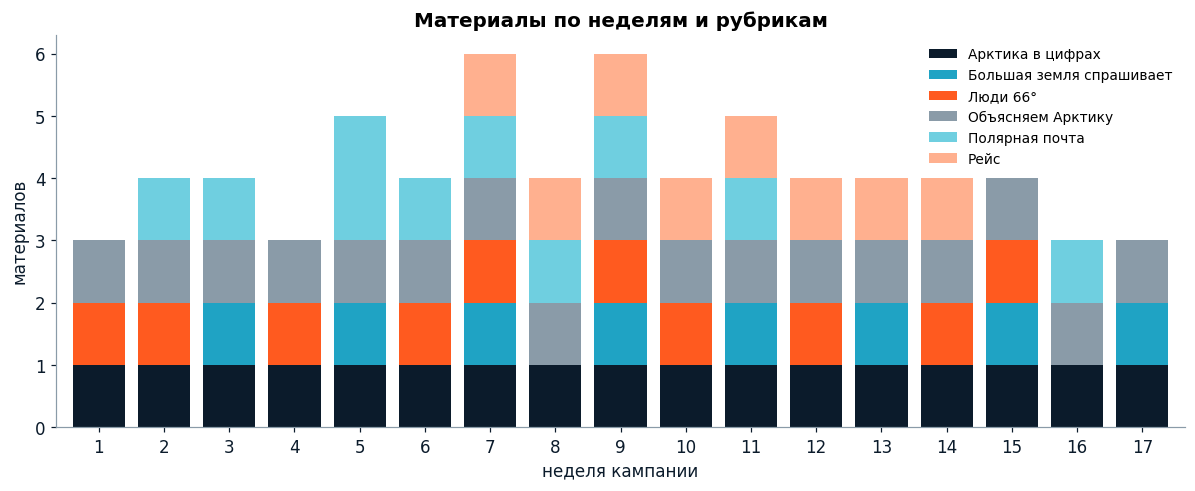

In [7]:
pivot = plan.pivot_table(index='Неделя', columns='Рубрика', values='Тема', aggfunc='count').fillna(0)
palette = [INK, CYAN, ORANGE, GREY, '#6FCFE0', '#FFB08F']
ax = pivot.plot(kind='bar', stacked=True, figsize=(11, 4.6), color=palette, width=0.8)
ax.set_title('Материалы по неделям и рубрикам'); ax.set_ylabel('материалов'); ax.set_xlabel('неделя кампании')
ax.legend(frameon=False, bbox_to_anchor=(1, 1), fontsize=9)
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig('output/content_plan.png', dpi=160); plt.show()

## 6. Скоринг лидеров мнений

Оцениваем категории по пяти критериям (1–5): охват, доверие, релевантность теме, органичность для Дзена, риски (чем выше балл, тем ниже риск). Веса отражают PR-логику кампании: доверие важнее охвата.

In [8]:
weights = {'Охват': 0.20, 'Доверие': 0.30, 'Релевантность': 0.25, 'Органичность для Дзена': 0.15, 'Низкий риск': 0.10}
kol = pd.DataFrame([
    ('Учёные и научные институты (ААНИИ, РГО, САФУ, МАГУ)', 2, 5, 5, 4, 5),
    ('Полярники и путешественники (Ф. Конюхов, М. Шпаро)', 4, 5, 5, 3, 4),
    ('Популяризаторы науки (В. Сурдин, С. Дробышевский)', 3, 5, 3, 4, 5),
    ('Авторы Дзена: путешествия, деньги, еда', 4, 3, 3, 5, 4),
    ('«Голоса Севера»: жители Арктики с каналами', 2, 5, 5, 5, 3),
    ('Федеральные журналисты и деловые СМИ', 4, 4, 4, 4, 4),
    ('Отраслевые спикеры (Росатом, НОВАТЭК, Норникель, ФЕСКО)', 3, 3, 5, 3, 3),
    ('Telegram-каналы про экономику и логистику', 3, 3, 4, 2, 3),
    ('Лайфстайл-блогеры-миллионники', 5, 2, 1, 3, 2),
], columns=['Категория'] + list(weights))
kol['Итоговый балл'] = sum(kol[k] * w for k, w in weights.items()).round(2)
kol = kol.sort_values('Итоговый балл', ascending=False).reset_index(drop=True)
kol.to_csv('output/kol_scoring.csv', index=False)
kol

,Категория,Охват,Доверие,Релевантность,Органичность для Дзена,Низкий риск,Итоговый балл
0,"Полярники и путешественники (Ф. Конюхов, М. Шпаро)",4,5,5,3,4,4.40
1,"Учёные и научные институты (ААНИИ, РГО, САФУ, МАГУ)",2,5,5,4,5,4.25
2,«Голоса Севера»: жители Арктики с каналами,2,5,5,5,3,4.20
3,Федеральные журналисты и деловые СМИ,4,4,4,4,4,4.00
4,"Популяризаторы науки (В. Сурдин, С. Дробышевский)",3,5,3,4,5,3.95
5,"Авторы Дзена: путешествия, деньги, еда",4,3,3,5,4,3.60
6,"Отраслевые спикеры (Росатом, НОВАТЭК, Норникель, ФЕСКО)",3,3,5,3,3,3.50
7,Telegram-каналы про экономику и логистику,3,3,4,2,3,3.10
8,Лайфстайл-блогеры-миллионники,5,2,1,3,2,2.50


Вывод: лайфстайл-миллионники дают охват, но проигрывают по доверию и релевантности — их в кампании нет. Ядро коллабораций — учёные, полярники и сами жители Севера. Охват добираем авторами Дзена и деловыми СМИ.

## 7. Модель виральной механики «Мой арктический след»

Механика: пользователь за минуту отвечает на пять бытовых вопросов и получает карточку «В вашей жизни N% Арктики». Каждая карточка сдвигает «ледокол Дзена» на 3 метра по карте Севморпути. Общая цель — пройти все 5 600 км, это ≈1,87 млн карточек.

Считаем по поколениям с недельным лагом:

`новые_t = посев_t + K × новые_(t−1)`, где `K = доля поделившихся × просмотры одного репоста × конверсия в прохождение`.

Три сценария различаются K и объёмом посева (продвижение в ленте Дзена, авторы, СМИ-партнёры).

In [9]:
ROUTE_KM, METERS_PER_CARD = 5600, 3
GOAL = ROUTE_KM * 1000 / METERS_PER_CARD
print(f'Цель: {GOAL:,.0f} карточек'.replace(',', ' '))

scenarios = {
    'пессимистичный': dict(share=0.15, views=6, conv=0.20, seed_k=0.80),
    'базовый':        dict(share=0.22, views=7, conv=0.25, seed_k=1.00),
    'оптимистичный':  dict(share=0.28, views=8, conv=0.28, seed_k=1.15),
}
base_seed = np.array([170, 160, 150, 140, 130, 120, 110, 100, 90, 80]) * 1000   # 10 недель: 12.01 — 22.03.2027
weeks_v = pd.date_range('2027-01-12', periods=len(base_seed), freq='7D')

res = {}
for name, p in scenarios.items():
    K = p['share'] * p['views'] * p['conv']
    seed = base_seed * p['seed_k']
    new = np.zeros(len(seed))
    for t in range(len(seed)):
        new[t] = seed[t] + (K * new[t - 1] if t else 0)
    cum = new.cumsum()
    hit = np.argmax(cum >= GOAL) + 1 if cum[-1] >= GOAL else None
    res[name] = dict(K=round(K, 3), seed_total=int(seed.sum()), total=int(cum[-1]),
                     viral_share=round(1 - seed.sum() / cum[-1], 3), shares=int(cum[-1] * p['share']),
                     km=round(cum[-1] * METERS_PER_CARD / 1000), goal_week=hit, cum=cum)

summary = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'cum'} for k, v in res.items()}).T
summary.columns = ['K-фактор', 'Посев', 'Всего карточек', 'Доля органики', 'Репостов', 'Пройдено км', 'Неделя достижения цели']
summary.to_csv('output/viral_model.csv')
summary

Цель: 1 866 667 карточек


,K-фактор,Посев,Всего карточек,Доля органики,Репостов,Пройдено км,Неделя достижения цели
пессимистичный,0.180,1000000.0,1201909.0,0.168,180286.0,3606.0,NaN
базовый,0.385,1250000.0,1944728.0,0.357,427840.0,5834.0,10.0
оптимистичный,0.627,1437500.0,3363078.0,0.573,941661.0,10089.0,6.0


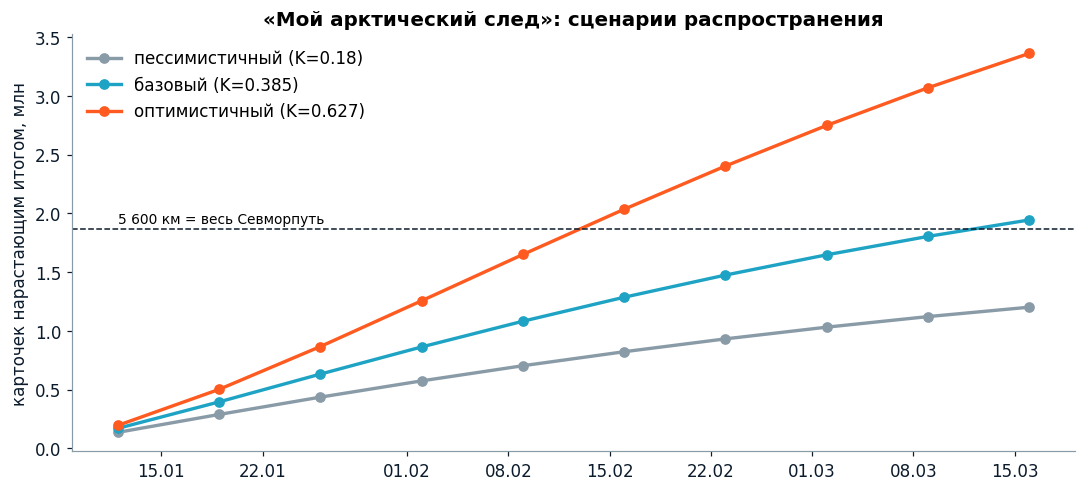

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.6))
for (name, r), c in zip(res.items(), [GREY, CYAN, ORANGE]):
    ax.plot(weeks_v, r['cum'] / 1e6, marker='o', color=c, lw=2.2, label=f"{name} (K={r['K']})")
ax.axhline(GOAL / 1e6, color=INK, ls='--', lw=1)
ax.text(weeks_v[0], GOAL / 1e6 + 0.05, '5 600 км = весь Севморпуть', fontsize=9)
ax.set_ylabel('карточек нарастающим итогом, млн'); ax.set_title('«Мой арктический след»: сценарии распространения')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
ax.legend(frameon=False); plt.tight_layout(); plt.savefig('output/viral_model.png', dpi=160); plt.show()

Чувствительность: какой K нужен, чтобы дойти до цели при базовом посеве. Это рабочий ориентир для еженедельного мониторинга — если K падает ниже порога, включаем дополнительный посев (авторы, пуш, СМИ-партнёры).

In [11]:
def total_for(K, seed=base_seed):
    new = np.zeros(len(seed))
    for t in range(len(seed)):
        new[t] = seed[t] + (K * new[t - 1] if t else 0)
    return new.sum()

grid = np.round(np.arange(0.20, 0.61, 0.05), 2)
sens = pd.DataFrame({'K': grid, 'карточек, млн': [round(total_for(k) / 1e6, 2) for k in grid]})
sens['дойдём до цели'] = sens['карточек, млн'] >= GOAL / 1e6
k_min = next(k for k in np.arange(0.2, 0.9, 0.005) if total_for(k) >= GOAL)
print(f'Минимальный K для достижения цели при базовом посеве: {k_min:.3f}')
sens

Минимальный K для достижения цели при базовом посеве: 0.360


,K,"карточек, млн",дойдём до цели
0,0.20,1.54,False
1,0.25,1.63,False
2,0.30,1.73,False
3,0.35,1.85,False
4,0.40,1.99,True
5,0.45,2.14,True
6,0.50,2.32,True
7,0.55,2.53,True
8,0.60,2.77,True


## 8. Медиамодель: охваты и инфоповоды

Оценка по каналам. Валовый охват пересекается, поэтому уникальный считаем с коэффициентом пересечения 0,55 — типичная величина для кампаний, где одна аудитория видит тему в нескольких каналах.

In [12]:
channels = pd.DataFrame([
    ('Дзен: хаб «Широта 66°» и рекомендации', 'owned', 22.0),
    ('«Арктический пул»: 50 СМИ-партнёров на Дзене', 'shared', 9.0),
    ('Публикации федеральных и региональных СМИ', 'earned', 8.0),
    ('Telegram-каналы и новые медиа', 'earned', 4.5),
    ('Авторы Дзена, «Голоса Севера», эксперты', 'shared', 6.0),
    ('Каналы партнёров (Росатом, РГО, Почта России и др.)', 'shared', 4.0),
], columns=['Канал', 'Тип', 'Валовый охват, млн'])
gross = channels['Валовый охват, млн'].sum()
unique = gross * 0.55
print(f'Валовый охват: {gross:.1f} млн, уникальный: ~{unique:.0f} млн')
channels.to_csv('output/reach_model.csv', index=False)

hooks = pd.DataFrame([
    ('Исследование «Что россияне знают об Арктике»', 'дек', 'федеральные, Telegram', 'данные, неожиданность'),
    ('Партнёрство Дзена с Ассоциацией полярников и РГО на форуме', 'дек', 'федеральные, деловые', 'госповестка'),
    ('Старт «Полярной почты»', 'дек', 'федеральные, региональные', 'эмоция, праздник'),
    ('Письма уходят на Север: сколько и откуда', 'дек', 'региональные', 'локальный угол'),
    ('Первые ответы полярников 1 января', 'янв', 'федеральные, ТВ', 'эмоция'),
    ('Премьера цикла «Рейс»', 'янв', 'федеральные, культура', 'эксклюзив'),
    ('Запуск «Моего арктического следа»', 'янв', 'новые медиа, Telegram', 'игра, личное участие'),
    ('Экспедиция авторов: 6 городов за 6 недель', 'янв–фев', 'региональные', 'люди, «сколько стоит жизнь»'),
    ('Региональный рейтинг «арктического следа»', 'фев', 'региональные', 'соревнование регионов'),
    ('Миллион карточек', 'фев', 'новые медиа', 'рекорд'),
    ('Ледокол Дзена прошёл Севморпуть: прямой эфир с Севера', 'мар', 'федеральные', 'коллективная цель'),
    ('Отчёт «Арктика в Дзене» и выставка писем на форуме в Мурманске', 'мар', 'федеральные, деловые, B2G', 'данные, госповестка'),
], columns=['Инфоповод', 'Месяц', 'Целевые медиа', 'Триггер'])
hooks.to_csv('output/news_hooks.csv', index=False)
channels

Валовый охват: 53.5 млн, уникальный: ~29 млн


,Канал,Тип,"Валовый охват, млн"
0,Дзен: хаб «Широта 66°» и рекомендации,owned,22.0
1,«Арктический пул»: 50 СМИ-партнёров на Дзене,shared,9.0
2,Публикации федеральных и региональных СМИ,earned,8.0
3,Telegram-каналы и новые медиа,earned,4.5
4,"Авторы Дзена, «Голоса Севера», эксперты",shared,6.0
5,"Каналы партнёров (Росатом, РГО, Почта России и др.)",shared,4.0


In [13]:
hooks

,Инфоповод,Месяц,Целевые медиа,Триггер
0,Исследование «Что россияне знают об Арктике»,дек,"федеральные, Telegram","данные, неожиданность"
1,Партнёрство Дзена с Ассоциацией полярников и РГО на форуме,дек,"федеральные, деловые",госповестка
2,Старт «Полярной почты»,дек,"федеральные, региональные","эмоция, праздник"
3,Письма уходят на Север: сколько и откуда,дек,региональные,локальный угол
4,Первые ответы полярников 1 января,янв,"федеральные, ТВ",эмоция
5,Премьера цикла «Рейс»,янв,"федеральные, культура",эксклюзив
6,Запуск «Моего арктического следа»,янв,"новые медиа, Telegram","игра, личное участие"
7,Экспедиция авторов: 6 городов за 6 недель,янв–фев,региональные,"люди, «сколько стоит жизнь»"
8,Региональный рейтинг «арктического следа»,фев,региональные,соревнование регионов
9,Миллион карточек,фев,новые медиа,рекорд


## 9. KPI и бюджет

KPI разбиты на три уровня: присутствие в повестке (PR), вовлечение (Дзен), репутация (бренд).

In [14]:
kpi = pd.DataFrame([
    ('PR', 'Публикации о кампании', '≥1 700', 'федеральные ≥70, региональные ≥450, Telegram ≥1 200', 'Медиалогия / Brand Analytics'),
    ('PR', 'Доля позитивных и нейтральных упоминаний', '≥90%', '', 'Медиалогия'),
    ('PR', 'Уникальный охват кампании', f'≈{unique:.0f} млн', 'по медиамодели', 'Дзен, мониторинг'),
    ('Дзен', 'Материалов в кор-проекте', f'{len(plan)}', 'шесть рубрик', 'CMS'),
    ('Дзен', 'Дочитывания лонгридов', '≥45%', 'ориентир выше среднего по платформе', 'статистика Дзена'),
    ('Дзен', 'Карточек «арктического следа»', f"≥{res['базовый']['total']/1e6:.1f} млн".replace('.', ','), 'базовый сценарий', 'интерактив'),
    ('Дзен', 'Писем «Полярной почты»', '≥120 тыс.', 'из всех регионов России', 'форма'),
    ('Дзен', 'СМИ в «Арктическом пуле»', '≥50', 'в т. ч. 15 региональных СМИ арктических регионов', 'B2M'),
    ('Поиск', 'Рост запросов «Северный морской путь»', '×1,5 к декабрю 2025 — марту 2026', '', 'Яндекс Вордстат'),
    ('Бренд', 'Ассоциация Дзена с новостями о нацпроектах', '+5 п. п.', 'брендлифт до/после', 'опрос'),
], columns=['Уровень', 'Метрика', 'Цель', 'Комментарий', 'Как меряем'])
kpi.to_csv('output/kpi.csv', index=False)

budget = pd.DataFrame([
    ('Документальный цикл «Рейс» (8 эпизодов)', 12.0),
    ('Экспедиция авторов и «Голоса Севера»', 6.5),
    ('«Полярная почта»: печать, логистика, офлайн-точки', 7.5),
    ('Интерактив «Мой арктический след» и карта', 4.5),
    ('Гонорары экспертов и лидеров мнений', 5.0),
    ('Исследования и отчёт «Арктика в Дзене»', 2.5),
    ('PR-сопровождение, события на форумах', 4.0),
    ('Резерв (≈10%)', 4.5),
], columns=['Статья', 'млн ₽'])
budget.to_csv('output/budget.csv', index=False)
print(f"Бюджет итого: {budget['млн ₽'].sum():.1f} млн ₽")
print(f"Стоимость контакта: {budget['млн ₽'].sum()*1e6/(unique*1e6):.2f} ₽ на уникального человека")
kpi

Бюджет итого: 46.5 млн ₽
Стоимость контакта: 1.58 ₽ на уникального человека


,Уровень,Метрика,Цель,Комментарий,Как меряем
0,PR,Публикации о кампании,≥1 700,"федеральные ≥70, региональные ≥450, Telegram ≥1 200",Медиалогия / Brand Analytics
1,PR,Доля позитивных и нейтральных упоминаний,≥90%,,Медиалогия
2,PR,Уникальный охват кампании,≈29 млн,по медиамодели,"Дзен, мониторинг"
3,Дзен,Материалов в кор-проекте,70,шесть рубрик,CMS
4,Дзен,Дочитывания лонгридов,≥45%,ориентир выше среднего по платформе,статистика Дзена
5,Дзен,Карточек «арктического следа»,"≥1,9 млн",базовый сценарий,интерактив
6,Дзен,Писем «Полярной почты»,≥120 тыс.,из всех регионов России,форма
7,Дзен,СМИ в «Арктическом пуле»,≥50,в т. ч. 15 региональных СМИ арктических регионов,B2M
8,Поиск,Рост запросов «Северный морской путь»,"×1,5 к декабрю 2025 — марту 2026",,Яндекс Вордстат
9,Бренд,Ассоциация Дзена с новостями о нацпроектах,+5 п. п.,брендлифт до/после,опрос


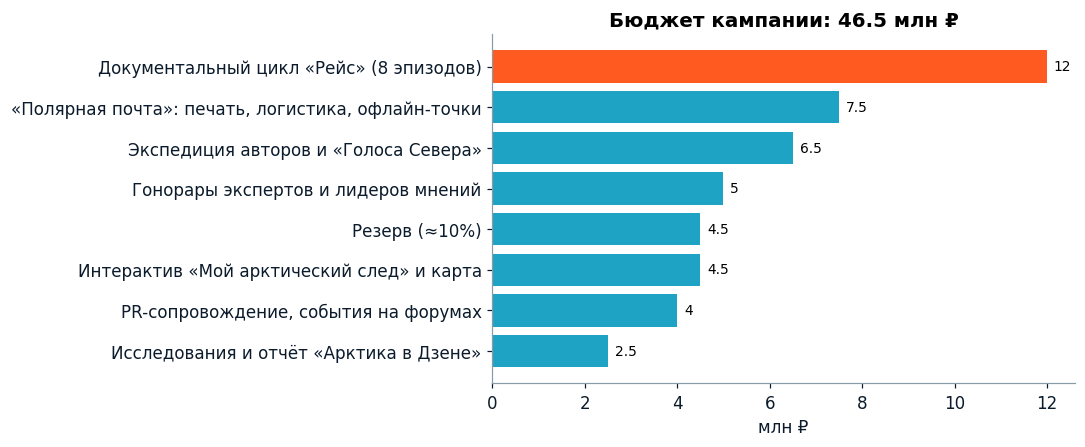

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.2))
b = budget.sort_values('млн ₽')
ax.barh(b['Статья'], b['млн ₽'], color=[ORANGE if 'Рейс' in s else CYAN for s in b['Статья']])
for y, v in enumerate(b['млн ₽']):
    ax.text(v + 0.15, y, f'{v:g}', va='center', fontsize=9)
ax.set_title(f"Бюджет кампании: {budget['млн ₽'].sum():.1f} млн ₽"); ax.set_xlabel('млн ₽')
plt.tight_layout(); plt.savefig('output/budget.png', dpi=160); plt.show()

## 10. Выводы

1. **Повестка есть, понимания нет.** Цифры по Севморпути растут, а цель на 2030 год в четыре раза выше нынешнего грузопотока. Отраслевые СМИ об этом пишут, массовая аудитория — почти нет. Это ниша Дзена: объяснять.
2. **2027-й — окно.** Проект указа о Годе Арктики и предложение объявить 2027-й Годом географии дают федеральные поводы на весь год. Кампания стартует в декабре, чтобы к январю Дзен уже был главным местом, где про Арктику рассказывают по-человечески.
3. **Доверие важнее охвата.** Скоринг показывает: ядро коллабораций — учёные, полярники и жители Севера. Охват добирают авторы Дзена и СМИ-партнёры.
4. **Виральность реалистична при K ≈ 0,3–0,4.** В базовом сценарии «Мой арктический след» набирает около 2 млн карточек и проходит весь Севморпуть к концу кампании. Контрольная точка — еженедельный K: если он ниже порога, усиливаем посев.
5. **Каждая аудитория получает своё.** Государство — данные о том, что людям непонятно. СМИ — трафик и эксклюзивы. Читатели — ответ на вопрос «при чём тут я».